In [1]:
### PRELUDE
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Add workspace to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
###

from src.seemps.analysis.mesh import RegularInterval
from src.seemps.analysis.expansion import PowerExpansion, mps_polynomial_expansion

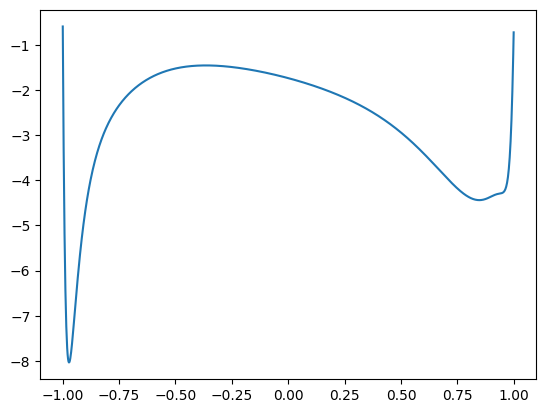

In [2]:
a, b = -1.0, 1.0
n = 10
N = 2**n
interval = RegularInterval(a, b, N, endpoint_right=True)

k = 100
rng = np.random.default_rng(8)
coeffs = rng.normal(loc=0.0, scale=1.0, size=k)
fn = lambda x: sum(c * x**i for i, c in enumerate(coeffs))

x = interval.to_vector()
y = fn(x)

plt.plot(x, y)

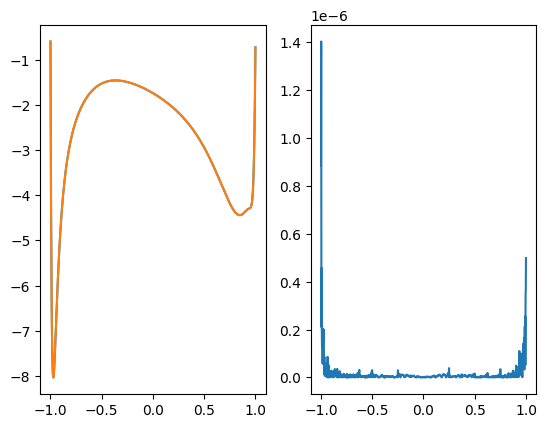

In [3]:
expansion = PowerExpansion(coeffs, (a, b))
mps = mps_polynomial_expansion(expansion, interval)

y_mps = mps.to_vector()

fig, axs = plt.subplots(ncols=2)
axs[0].plot(x, y)
axs[0].plot(x, y_mps)
axs[1].plot(x, np.abs(y_mps - y))